# N7 — Skills: Capacidades Reutilizáveis para Agentes

* Professor: Julio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a> 

Este notebook introduzir o conceito de **skill**: uma capacidade reutilizável que encapsula comportamento, workflow, ferramentas e conhecimento especializado sobre como resolver uma tarefa específica.

A proposta é entender skill como uma camada de **conhecimento procedural sob demanda**, que orienta o agente sobre *quando* e *como* usar as capacidades que ele já possui (tools locais, servidores MCP, scripts), em vez de mais uma capacidade nova para executar ações.

Nas aulas anteriores, trabalhamos com:

- fundamentos conceituais de agentes;
- grafos de execução com LangGraph;
- chamadas de LLM dentro de grafos;
- tools, tool calling e agentes ReAct;
- Model Context Protocol (MCP) como padrão de integração com sistemas externos.



## 0.1 Pré-requisitos

Para acompanhar este notebook, é esperado que você já tenha:

- entendido o papel de tools em agentes baseados em LLMs (notebook de Ferramentas);
- visto o padrão ReAct em alto nível;
- alguma familiaridade com MCP, especialmente as ideias de descoberta de capacidades e servidores externos;
- noções de `StateGraph`, nós e arestas condicionais em LangGraph;
- familiaridade básica com dataclasses e dicionários em Python.

Não é necessário nenhum pacote específico de "skills" instalado. Vamos implementar uma **simulação didática** do conceito usando Python puro, e depois conectar essa simulação a um agente real em LangGraph.

## 0.2 Objetivos da aula

Ao final deste notebook, você necessita:

1. Entender o que é uma skill e por que ela é diferente de uma tool.
2. Descrever a anatomia típica de uma skill (`SKILL.md`, metadados, corpo, recursos).
3. Explicar o mecanismo de *progressive disclosure* em três níveis.
4. Modelar skills como estruturas de dados em Python.
5. Construir um pequeno sistema de descoberta e ativação de skills.
6. Usar uma skill para orquestrar tools já existentes.
7. Integrar skills a um agente real em LangGraph.
8. Discutir composição, modularidade e escalabilidade de skills.
9. Comparar skills, tools e MCP dentro de uma mesma arquitetura.

## 0.3 Mapa do notebook

Este notebook aborda:

1. O problema: conhecimento processual repetido no prompt.
2. O que é uma skill.
3. Anatomia de uma skill.
4. Modelando uma skill em Python.
5. Progressive disclosure: os três níveis de carregamento.
6. Um mini-sistema de skills didático.
7. Skills orquestrando tools existentes.
8. Integrando skills a um agente LangGraph.
9. Composição de skills.
10. Skills, tools e MCP juntos.
11. Boas práticas para escrever skills.
12. Exercícios de fixação.
13. Resumo da aula.
14. Referências.

## 0.4 Contexto usado nos exemplos

Para manter continuidade com os notebooks anteriores, vamos usar o mesmo cenário geral:

- existe um **curso sobre agentes com LLMs e LangGraph**, organizado em módulos (A4, A5, A6, A7...);
- o módulo **A6** introduziu tools e o padrão ReAct;
- o módulo **A7** introduziu MCP como camada de integração;
- agora, no módulo **A8**, queremos ensinar o agente do curso a seguir **procedimentos específicos** de forma consistente — por exemplo, como montar um plano de estudos, ou como revisar o progresso de um aluno antes de liberar um novo módulo.

Vamos reaproveitar duas tools que já existem em nosso exemplo didático:

- `calcular_carga_total`: calcula carga horária de aulas (vista no notebook de Ferramentas);
- `consultar_progresso_aluno`: consulta o progresso de um aluno (vista no notebook de MCP).

E vamos criar uma **skill** chamada `planejar-estudo`, que orquestra essas tools seguindo um procedimento específico definido por um instrutor humano.

---

## 0.5 Preparação do ambiente

Este notebook assume que você já tem LangChain, LangGraph e um provedor de LLM configurados, como nos notebooks anteriores.

> Importante: para os exemplos com tool calling, escolha um modelo que suporte **tool calling**. Os exemplos manuais de descoberta e ativação de skill funcionam mesmo sem chamar uma LLM.

In [28]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
%pip install -U langchain langchain-core langgraph langchain-openai python-dotenv rich

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Agora importamos os elementos que serão usados ao longo da aula.

In [29]:
from __future__ import annotations

import json
import os
from dataclasses import dataclass, field
from typing import Annotated, Any, Callable, Dict, List, Literal, Optional, TypedDict

from dotenv import load_dotenv

from langchain.chat_models import init_chat_model
from langchain.tools import tool as tool_decorator
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph

from IPython.display import Image, display
from rich import print
from rich.markdown import Markdown

Esses imports combinam elementos de dois níveis:

- **LangChain Core**: mensagens e tools;
- **LangGraph**: orquestração explícita do loop agente → decisão → ação → observação.

A parte de "skills" propriamente dita não vem de nenhum pacote — vamos modelá-la nós mesmos.

In [33]:
def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


def print_messages(messages: list[BaseMessage]) -> None:
    """Imprime uma conversa de maneira compacta."""
    for index, message in enumerate(messages):
        print(f"\nMensagem {index} — {message.__class__.__name__}")
        if isinstance(message, AIMessage) and message.tool_calls:
            print("tool_calls:")
            print(message.tool_calls)
        else:
            print(message.content)


def print_json(value: Any) -> None:
    """Imprime objetos Python como JSON formatado."""
    print(json.dumps(value, ensure_ascii=False, indent=2))

Agora inicializamos o modelo, seguindo o mesmo padrão dos notebooks anteriores.

Substitua o `MODEL_ID` pelo modelo configurado no seu ambiente — o importante é que ele suporte **tool calling**.

In [32]:
load_dotenv()
print("Chave OPENAI_API_KEY configurada com sucesso." if "OPENAI_API_KEY" in os.environ else "Chave não encontrada.")

llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

Chave OPENAI_API_KEY configurada com sucesso.

# 1. O problema: conhecimento processual repetido no prompt

Imagine que, no agente do curso, queremos que ele saiba montar um **plano de estudo** para um aluno.

Sem nenhum mecanismo especial, isso normalmente é resolvido de uma forma pouco elegante: colocar o procedimento inteiro dentro do system prompt, sempre, mesmo quando o aluno só quer saber a carga horária de uma aula.

Vamos simular esse problema.

In [34]:
SYSTEM_PROMPT_SEM_SKILLS = """
Você é o assistente do curso de agentes com LLMs e LangGraph.

Quando o aluno pedir um plano de estudo, siga EXATAMENTE este procedimento:
1. Consulte o progresso do aluno com a tool consultar_progresso_aluno.
2. Identifique o módulo atual e a dificuldade relatada.
3. Calcule a carga horária restante com calcular_carga_total.
4. Sugira no máximo 3 blocos de estudo por semana.
5. Sempre termine perguntando se o aluno quer revisar algum módulo anterior.
6. Nunca invente módulos que não existem no plano curricular do curso.
7. Nunca prometa datas de conclusão sem calcular a carga horária primeiro.
... (mais 40 linhas de instruções de outros procedimentos: revisão de exercícios,
     aprovação de mudança de turma, geração de certificado, etc.)
"""

print(f"Tamanho aproximado do system prompt: {len(SYSTEM_PROMPT_SEM_SKILLS)} caracteres")

Tamanho aproximado do system prompt: 751 caracteres

O problema não é só o tamanho. É que **todo esse procedimento entra no contexto em toda mensagem**, mesmo quando o aluno só pergunta "quantas aulas tem o módulo A5?".

Multiplique isso por dezenas de procedimentos diferentes (plano de estudo, revisão de exercício, aprovação de turma, emissão de certificado...) e o prompt fica:

- caro em tokens, sempre;
- difícil de manter (qualquer ajuste mexe num arquivo gigante);
- sujeito a "diluir" a atenção do modelo mesmo em tarefas simples.

É exatamente esse problema que o conceito de **skill** tenta resolver: manter o conhecimento procedural fora do contexto por padrão, e trazê-lo só quando a tarefa realmente pedir.

# 2. O que é uma skill

Uma **skill** é uma capacidade reutilizável que encapsula:

- um **comportamento** ou **workflow** específico (uma sequência de passos a seguir);
- as **tools** que devem ser usadas para executar esse workflow;
- **conhecimento especializado** sobre aquele domínio (regras, convenções, formato esperado de resposta).

O ponto central é que uma skill **não é uma nova capacidade de ação**. O agente já sabia chamar `consultar_progresso_aluno` e `calcular_carga_total` antes de qualquer skill existir. O que a skill acrescenta é o **procedimento**: em que ordem chamar essas tools, com que critérios, e como formatar o resultado.

> Skill está para conhecimento processual assim como tool está para capacidade de ação.

## 2.1 Skill não é tool

| | Tool | Skill |
|---|---|---|
| O que é | Uma função chamável, com schema de entrada/saída | Um procedimento em texto (instruções) |
| Quem executa | O runtime da aplicação, ao processar `tool_calls` | O próprio modelo, seguindo as instruções lidas |
| Carregamento | Nome + descrição sempre visíveis (ou sob demanda, com *tool search*) | Metadados sempre visíveis; corpo completo só quando ativada |
| Papel | Dá ao agente a capacidade de *fazer* algo | Dá ao agente o conhecimento de *como* fazer bem |

# 3. Anatomia de uma skill

Na prática (fora deste notebook, em ferramentas como Claude Code ou `deepagents`), uma skill costuma ser um diretório com, no mínimo, um arquivo `SKILL.md`:

```text
planejar-estudo/
├── SKILL.md        # obrigatório: metadados + instruções
├── scripts/         # opcional: código auxiliar executável
├── references/      # opcional: documentação de apoio
└── assets/          # opcional: templates, recursos estáticos
```

## 3.1 Metadados (frontmatter)

A parte mais importante da skill, porque é a única coisa que fica **sempre visível** para o agente antes de qualquer ativação:

```yaml
---
name: planejar-estudo
description: Monta um plano de estudo semanal considerando progresso e carga horária restante do aluno
---
```

## 3.2 Corpo (instruções)

O procedimento propriamente dito, em linguagem natural — passos, critérios, formato de resposta esperado.

## 3.3 Recursos adicionais

Scripts, templates e documentação de apoio, carregados apenas se as instruções do corpo mandarem consultá-los.

Vamos modelar essa estrutura em Python.

# 4. Modelando uma skill em Python

Vamos representar uma skill como uma estrutura de dados simples, com os mesmos campos que existiriam em um `SKILL.md`.

In [35]:
@dataclass
class Skill:
    name: str
    description: str
    body: str
    tools_relacionadas: List[str] = field(default_factory=list)

    def metadados(self) -> dict:
        """Retorna apenas o que fica sempre visível (nível de descoberta)."""
        return {"name": self.name, "description": self.description}

    def conteudo_completo(self) -> str:
        """Retorna o corpo completo da skill (nível de ativação)."""
        return self.body

Agora criamos a skill `planejar-estudo`, escrita como um instrutor humano escreveria.

In [37]:
skill_planejar_estudo = Skill(
    name="planejar-estudo",
    description=(
        "Monta um plano de estudo semanal para um aluno do curso, considerando "
        "progresso atual, dificuldade relatada e carga horária restante."
    ),
    tools_relacionadas=["consultar_progresso_aluno", "calcular_carga_total"],
    body="""
# Planejar estudo

## Quando usar
Use esta skill quando o aluno pedir um plano, cronograma ou sugestão de estudo
para as próximas semanas.

## Passos
1. Consulte o progresso do aluno com a tool `consultar_progresso_aluno`.
2. Identifique o módulo atual e a dificuldade relatada.
3. Calcule a carga horária restante com `calcular_carga_total`, assumindo
   50 minutos por aula, a menos que o aluno informe outro valor.
4. Distribua o estudo em no máximo 3 blocos por semana.
5. Priorize revisar a dificuldade relatada antes de avançar para o próximo módulo.

## Formato da resposta
- Liste os blocos de estudo em tópicos, com o foco de cada bloco.
- Termine perguntando se o aluno quer revisar algum módulo anterior.

## Cuidados
- Nunca invente módulos que não existem no plano curricular do curso.
- Nunca sugira um plano sem antes consultar o progresso real do aluno.
""",
)

print(f"Skill '{skill_planejar_estudo.name}' criada.")
print_json(skill_planejar_estudo.metadados())

Skill 'planejar-estudo' criada.

{
  "name": "planejar-estudo",
  "description": "Monta um plano de estudo semanal para um aluno do curso, considerando progresso atual, 
dificuldade relatada e carga horária restante."
}

# 5. Progressive disclosure: os três níveis

O mecanismo central por trás de skills é carregar informação em camadas, para não estourar o contexto com conhecimento que talvez nunca seja usado naquela conversa.

## 5.1 Nível 1 — Descoberta

Só `name` + `description` de **todas** as skills disponíveis ficam sempre visíveis, geralmente embutidas no system prompt.

## 5.2 Nível 2 — Ativação

O corpo completo da skill entra no contexto **somente quando o agente decide** que a tarefa combina com a descrição.

## 5.3 Nível 3 — Recursos

Arquivos de apoio (`scripts/`, `references/`, `assets/`) só são lidos se as instruções do corpo mandarem consultá-los — o que não vamos simular em detalhe aqui, mas fica registrado como extensão possível.

Vamos implementar os níveis 1 e 2 com um pequeno "catálogo" de skills.

# 6. Um mini-sistema de skills

Vamos criar um `SkillRegistry`, parecido com o `MiniMCPServer` (do notebook anterior): ele guarda as skills disponíveis e sabe responder a dois tipos de pedido — "quais skills existem?" (nível 1) e "me dê o conteúdo completo desta skill" (nível 2).

In [39]:
class SkillRegistry:
    def __init__(self):
        self._skills: Dict[str, Skill] = {}

    def registrar(self, skill: Skill) -> None:
        self._skills[skill.name] = skill

    def descobrir(self) -> List[dict]:
        """Nível 1: retorna apenas os metadados de todas as skills."""
        return [skill.metadados() for skill in self._skills.values()]

    def ativar(self, name: str) -> str:
        """Nível 2: retorna o conteúdo completo de uma skill específica."""
        if name not in self._skills:
            disponiveis = list(self._skills.keys())
            raise ValueError(f"Skill '{name}' não encontrada. Disponíveis: {disponiveis}")

        return self._skills[name].conteudo_completo()


registry = SkillRegistry()
registry.registrar(skill_planejar_estudo)

print_json(registry.descobrir())

[
  {
    "name": "planejar-estudo",
    "description": "Monta um plano de estudo semanal para um aluno do curso, considerando progresso atual, 
dificuldade relatada e carga horária restante."
  }
]

Se o agente decidir ativar a skill, ele recebe o conteúdo completo:

In [40]:
print(Markdown(registry.ativar("planejar-estudo")))

Planejar estudo                                                  

Quando usar                                                                                                        

Use esta skill quando o aluno pedir um plano, cronograma ou sugestão de estudo para as próximas semanas.           

Passos                                                                                                             

 1 Consulte o progresso do aluno com a tool consultar_progresso_aluno.                                             
 2 Identifique o módulo atual e a dificuldade relatada.                                                            
 3 Calcule a carga horária restante com calcular_carga_total, assumindo 50 minutos por aula, a menos que o aluno   
   informe outro valor.                                                                                            
 4 Distribua o estudo em no máximo 3 blocos por semana.                                                            
 5 Priorize revisar a dificuldade relatada antes de avançar para o próximo módulo.                                 

Formato da resposta                                                                                                

 • Liste os blocos de estudo em tópicos, com o foco de cada bloco.                                                 
 • Termine perguntando se o aluno quer revisar algum módulo anterior.                                              

Cuidados                                                                                                           

 • Nunca invente módulos que não existem no plano curricular do curso.                                             
 • Nunca sugira um plano sem antes consultar o progresso real do aluno.

Note a diferença de custo entre os dois níveis: `descobrir()` devolve poucas dezenas de tokens por skill; `ativar()` devolve o procedimento inteiro, e só é chamado quando necessário.

# 7. Skills orquestrando tools existentes

Skills não substituem tools — elas orquestram tools que já existem. Vamos recriar, de forma simplificada, as duas tools referenciadas na skill `planejar-estudo`.

In [41]:
PROGRESSO_ALUNOS = {
    "ana": {
        "modulo_atual": "A7",
        "dificuldade_atual": "diferenciar tool local de servidor MCP",
    },
    "bruno": {
        "modulo_atual": "A5",
        "dificuldade_atual": "roteamento condicional com LLM",
    },
}


@tool_decorator
def consultar_progresso_aluno(nome_aluno: str) -> str:
    """Consulta o módulo atual e a dificuldade relatada de um aluno do curso.

    Use quando precisar saber em que módulo o aluno está ou qual dificuldade
    ele relatou recentemente.
    """
    chave = nome_aluno.lower()

    if chave not in PROGRESSO_ALUNOS:
        return json.dumps({"erro": "aluno_nao_encontrado", "alunos_disponiveis": list(PROGRESSO_ALUNOS.keys())})

    return json.dumps({"aluno": chave, **PROGRESSO_ALUNOS[chave]}, ensure_ascii=False)


@tool_decorator
def calcular_carga_total(quantidade_aulas: int, minutos_por_aula: int = 50) -> str:
    """Calcula a carga horária total de uma sequência de aulas do curso.

    Use quando for necessário calcular a duração total de aulas ou módulos restantes.
    """
    total_minutos = quantidade_aulas * minutos_por_aula
    horas, minutos = divmod(total_minutos, 60)

    return json.dumps(
        {
            "quantidade_aulas": quantidade_aulas,
            "minutos_por_aula": minutos_por_aula,
            "total_formatado": f"{horas}h{minutos:02d}min",
        },
        ensure_ascii=False,
    )


tools_do_curso = [consultar_progresso_aluno, calcular_carga_total]
tools_por_nome = {tool.name: tool for tool in tools_do_curso}

print("Tools disponíveis:", list(tools_por_nome.keys()))

Tools disponíveis:
['consultar_progresso_aluno', 'calcular_carga_total']

Essas são exatamente as tools que a skill `planejar-estudo` referencia em `tools_relacionadas`. 

A skill não as reimplementa — ela apenas descreve **em que ordem e com que critério** usá-las.

# 8. Integrando skills a um agente LangGraph

Agora vamos transformar isso em um agente real. A ideia:

1. O agente conhece a lista de skills disponíveis desde o início (nível 1), injetada no system prompt.
2. Damos ao agente uma tool `read_skill`, que ativa uma skill (nível 2) sob demanda.
3. Depois de ler a skill, o agente segue as instruções e chama as tools do curso normalmente.

## 8.1 Tool de ativação de skill

Vamos expor `registry.ativar` como uma tool comum, chamável pelo modelo como qualquer outra.

In [42]:
@tool_decorator
def read_skill(name: str) -> str:
    """Lê o conteúdo completo de uma skill pelo nome, para seguir o procedimento descrito.

    Use quando a tarefa do aluno combinar com a descrição de alguma skill disponível.
    """
    try:
        return registry.ativar(name)
    except ValueError as erro:
        return json.dumps({"erro": str(erro)}, ensure_ascii=False)


todas_as_tools = tools_do_curso + [read_skill]
tools_por_nome = {tool.name: tool for tool in todas_as_tools}

llm_com_tools = llm.bind_tools(todas_as_tools)

## 8.2 System prompt com descoberta de skills

O system prompt injeta só os metadados (nível 1) — nunca o corpo completo das skills.

In [43]:
def montar_system_prompt() -> str:
    skills_disponiveis = registry.descobrir()
    lista_skills = "\n".join(
        f"- {skill['name']}: {skill['description']}" for skill in skills_disponiveis
    )

    return f"""Você é o assistente do curso de agentes com LLMs e LangGraph.

Você tem acesso às seguintes skills:

{lista_skills}

Se a tarefa do aluno combinar com a descrição de alguma skill, use a tool
read_skill para carregar as instruções completas antes de agir. Só então
use as demais tools disponíveis, seguindo o procedimento descrito na skill.
"""


print(montar_system_prompt())

Você é o assistente do curso de agentes com LLMs e LangGraph.

Você tem acesso às seguintes skills:

- planejar-estudo: Monta um plano de estudo semanal para um aluno do curso, considerando progresso atual, 
dificuldade relatada e carga horária restante.

Se a tarefa do aluno combinar com a descrição de alguma skill, use a tool
read_skill para carregar as instruções completas antes de agir. Só então
use as demais tools disponíveis, seguindo o procedimento descrito na skill.

## 8.3 Estado do agente

O estado principal continua sendo `messages`, com `add_messages` como reducer.

In [44]:
class SkillAgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    steps: int

## 8.4 Nó da LLM

In [45]:
def llm_node(state: SkillAgentState):
    response = llm_com_tools.invoke(
        [
            SystemMessage(content=montar_system_prompt()),
            *state["messages"],
        ]
    )

    return {
        "messages": [response],
        "steps": state.get("steps", 0) + 1,
    }

## 8.5 Nó de tools

In [46]:
def executar_tool_calls(last_message: AIMessage) -> list[ToolMessage]:
    tool_messages = []

    for tool_call in last_message.tool_calls:
        nome_tool = tool_call["name"]

        if nome_tool not in tools_por_nome:
            conteudo = json.dumps({"erro": "tool_desconhecida", "tool": nome_tool})
        else:
            conteudo = tools_por_nome[nome_tool].invoke(tool_call["args"])

        tool_messages.append(
            ToolMessage(content=conteudo, tool_call_id=tool_call["id"])
        )

    return tool_messages


def tools_node(state: SkillAgentState):
    last_message = state["messages"][-1]
    return {"messages": executar_tool_calls(last_message)}

## 8.6 Função de roteamento

In [47]:
def should_continue(state: SkillAgentState) -> Literal["tools", END]:
    last_message = state["messages"][-1]

    if getattr(last_message, "tool_calls", None) and state.get("steps", 0) < 6:
        return "tools"

    return END

## 8.7 Construindo o grafo

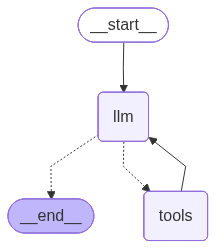

In [48]:
builder = StateGraph(SkillAgentState)

builder.add_node("llm", llm_node)
builder.add_node("tools", tools_node)

builder.add_edge(START, "llm")

builder.add_conditional_edges(
    "llm",
    should_continue,
    {
        "tools": "tools",
        END: END,
    },
)

builder.add_edge("tools", "llm")

skill_agent_graph = builder.compile()

display_graph(skill_agent_graph)

## 8.8 Executando o agente com skills

In [49]:
resultado = skill_agent_graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="Sou o Bruno. Pode montar um plano de estudo pra mim essa semana?"
            )
        ],
        "steps": 0,
    }
)

print_messages(resultado["messages"])

Mensagem 0 — HumanMessage

Sou o Bruno. Pode montar um plano de estudo pra mim essa semana?

Mensagem 1 — AIMessage

tool_calls:

[
    {
        'name': 'consultar_progresso_aluno',
        'args': {'nome_aluno': 'Bruno'},
        'id': 'call_xPfdFL17gkTZadChhTKopkIl',
        'type': 'tool_call'
    }
]

...

[
    {
        'name': 'read_skill',
        'args': {'name': 'planejar-estudo'},
        'id': 'call_jkKkiMvPdS5NHVKJ7AGoP2BC',
        'type': 'tool_call'
    }
]

Mensagem 6 — ToolMessage

# Planejar estudo

## Quando usar
Use esta skill quando o aluno pedir um plano, cronograma ou sugestão de estudo
para as próximas semanas.

## Passos
1. Consulte o progresso do aluno com a tool `consultar_progresso_aluno`.
2. Identifique o módulo atual e a dificuldade relatada.
3. Calcule a carga horária restante com `calcular_carga_total`, assumindo
   50 minutos por aula, a menos que o aluno informe outro valor.
4. Distribua o estudo em no máximo 3 blocos por semana.
5. Priorize revisar a dificuldade relatada antes de avançar para o próximo módulo.

## Formato da resposta
- Liste os blocos de estudo em tópicos, com o foco de cada bloco.
- Termine perguntando se o aluno quer revisar algum módulo anterior.

## Cuidados
- Nunca invente módulos que não existem no plano curricular do curso.
- Nunca sugira um plano sem antes consultar o progresso real do aluno.

Mensagem 7 — AIMessage

Aqui está o seu plano de estudo para esta semana, Bruno:

### Bloco 1: Roteamento Condicional com LLM
- **Duração:** 1h30min
- **Atividades:** Revisar conceitos de roteamento condicional, assistir aulas e fazer anotações.

### Bloco 2: Prática de Roteamento Condicional
- **Duração:** 1h30min
- **Atividades:** Realizar exercícios práticos relacionados ao roteamento condicional, aplicando o que foi 
aprendido.

### Bloco 3: Revisão e Dúvidas
- **Duração:** 1h10min
- **Atividades:** Revisar os pontos mais desafiadores do módulo A5 e esclarecer dúvidas.

Você gostaria de revisar algum módulo anterior?

Observe o que aconteceu nesse procedimento:

1. O modelo viu, no system prompt, só o nome e a descrição da skill `planejar-estudo`.
2. Reconheceu que "montar um plano de estudo" combina com essa descrição.
3. Chamou `read_skill("planejar-estudo")` para carregar o procedimento completo.
4. Seguiu os passos descritos: consultou o progresso do Bruno, calculou a carga horária, e formatou a resposta em blocos semanais.

Nenhuma dessas etapas foi *hardcoded* no grafo — o grafo só sabe alternar entre "chamar o modelo" e "executar tools". 

Todo o procedimento específico estava descrito na skill.

Agora testamos uma pergunta que **não** combina com nenhuma skill disponível, para confirmar que o agente não ativa a skill à toa.

In [50]:
resultado_simples = skill_agent_graph.invoke(
    {
        "messages": [
            HumanMessage(content="Quantas horas são 8 aulas de 45 minutos?")
        ],
        "steps": 0,
    }
)

print_messages(resultado_simples["messages"])

Mensagem 0 — HumanMessage

Quantas horas são 8 aulas de 45 minutos?

Mensagem 1 — AIMessage

tool_calls:

[
    {
        'name': 'calcular_carga_total',
        'args': {'quantidade_aulas': 8, 'minutos_por_aula': 45},
        'id': 'call_9L6kxfzxzFhvFPHSW4cIy9KN',
        'type': 'tool_call'
    }
]

Mensagem 2 — ToolMessage

{"quantidade_aulas": 8, "minutos_por_aula": 45, "total_formatado": "6h00min"}

Mensagem 3 — AIMessage

8 aulas de 45 minutos totalizam 6 horas.

Nesse segundo caso, o esperado é que o modelo chame diretamente `calcular_carga_total`, sem passar por `read_skill` — a pergunta não tem nada a ver com a descrição da skill `planejar-estudo`.

# 9. Composição de skills

Conforme o número de procedimentos cresce, skills adicionais podem ser registradas sem tocar nas existentes — isso é o que dá modularidade e escalabilidade ao sistema.

Vamos adicionar uma segunda skill, `revisar-antes-de-avancar`, que decide se um aluno já pode avançar de módulo.

In [51]:
skill_revisar_antes_de_avancar = Skill(
    name="revisar-antes-de-avancar",
    description=(
        "Avalia se um aluno pode avançar para o próximo módulo, com base na "
        "dificuldade relatada no progresso atual."
    ),
    tools_relacionadas=["consultar_progresso_aluno"],
    body="""
# Revisar antes de avançar

## Quando usar
Use quando o aluno perguntar se já pode avançar, começar ou liberar um novo módulo.

## Passos
1. Consulte o progresso do aluno com `consultar_progresso_aluno`.
2. Se houver uma dificuldade relatada, NÃO recomende avançar — recomende revisar
   especificamente aquele ponto antes.
3. Se não houver dificuldade relatada, recomende avançar normalmente.

## Formato da resposta
Responda com uma recomendação direta (pode avançar / ainda não) seguida de
uma justificativa curta baseada no progresso consultado.
""",
)

registry.registrar(skill_revisar_antes_de_avancar)

print_json(registry.descobrir())

[
  {
    "name": "planejar-estudo",
    "description": "Monta um plano de estudo semanal para um aluno do curso, considerando progresso atual, 
dificuldade relatada e carga horária restante."
  },
  {
    "name": "revisar-antes-de-avancar",
    "description": "Avalia se um aluno pode avançar para o próximo módulo, com base na dificuldade relatada no 
progresso atual."
  }
]

Note que:

- registrar uma nova skill não exigiu nenhuma mudança no grafo, nos nós ou na tool `read_skill`;
- o custo de contexto por padrão cresceu só mais uma linha no system prompt (os metadados);
- as duas skills podem compartilhar a mesma tool (`consultar_progresso_aluno`) sem conflito.

Isso ilustra a vantagem central de modelar conhecimento processual como skills separadas em vez de um único bloco de instruções: **cada skill pode ser mantida, testada e evoluída de forma isolada**, e o conjunto inteiro escala sem inflar o custo por conversa.

In [52]:
resultado_revisao = skill_agent_graph.invoke(
    {
        "messages": [
            HumanMessage(content="Sou a Ana. Já posso avançar pro próximo módulo?")
        ],
        "steps": 0,
    }
)

print_messages(resultado_revisao["messages"])

Mensagem 0 — HumanMessage

Sou a Ana. Já posso avançar pro próximo módulo?

Mensagem 1 — AIMessage

tool_calls:

[
    {
        'name': 'consultar_progresso_aluno',
        'args': {'nome_aluno': 'Ana'},
        'id': 'call_jsfKivLbnZGnohJ9x4SufLi5',
        'type': 'tool_call'
    }
]

...

[
    {
        'name': 'read_skill',
        'args': {'name': 'revisar-antes-de-avancar'},
        'id': 'call_UQKpEoGnGIjNL4qOmdVghN9U',
        'type': 'tool_call'
    }
]

Mensagem 4 — ToolMessage

# Revisar antes de avançar

## Quando usar
Use quando o aluno perguntar se já pode avançar, começar ou liberar um novo módulo.

## Passos
1. Consulte o progresso do aluno com `consultar_progresso_aluno`.
2. Se houver uma dificuldade relatada, NÃO recomende avançar — recomende revisar
   especificamente aquele ponto antes.
3. Se não houver dificuldade relatada, recomende avançar normalmente.

## Formato da resposta
Responda com uma recomendação direta (pode avançar / ainda não) seguida de
uma justificativa curta baseada no progresso consultado.

Mensagem 5 — AIMessage

Ainda não pode avançar. Você relatou dificuldade em diferenciar a tool local de servidor MCP, e é importante 
revisar esse ponto antes de seguir para o próximo módulo.

Um ponto importante de composição: nada impede que o **corpo de uma skill referencie outra**. Por exemplo, a skill `planejar-estudo` poderia incluir um passo dizendo "antes de montar o plano, siga também os critérios da skill `revisar-antes-de-avancar`". Isso não é um mecanismo especial — é só texto guiando o próprio modelo a chamar `read_skill` novamente, encadeando ativações conforme necessário.

# 10. Skills, tools e MCP juntos

Juntando os três notebooks recentes, fica mais claro como as peças se encaixam em uma arquitetura real:

| Camada | Pergunta que responde | O que vimos neste curso |
|---|---|---|
| **Tool** | O que o agente consegue *executar*? | `calcular_carga_total`, `consultar_progresso_aluno` |
| **MCP** | Como o agente se conecta a *sistemas externos* de forma padronizada? | `CursoMCPServer`, `AlunoMCPServer` |
| **Skill** | *Como* o agente deve combinar tools (locais ou via MCP) para resolver uma tarefa específica? | `planejar-estudo`, `revisar-antes-de-avancar` |

Uma skill pode perfeitamente orquestrar uma tool que, internamente em sua implementação, é servida por um servidor MCP — o corpo da skill não muda dependendo de onde a tool "mora". 

Do ponto de vista do procedimento descrito na skill, chamar uma tool local ou uma tool exposta por MCP é a mesma coisa: uma chamada nomeada, com argumentos, que devolve uma observação.

```text
SKILL (orquestração)
  │
  ├── tool local (função Python)
  ├── tool via MCP (servidor externo)
  └── script auxiliar (scripts/)
```

# 11. Boas práticas para escrever skills

## 11.1 A descrição é o que mais importa

Se a `description` for vaga, o agente nunca vai ativar a skill certa (ou vai ativar a errada). Prefira:

```yaml
description: Monta um plano de estudo semanal considerando progresso e carga horária restante do aluno
```

Evite:

```yaml
description: Ajuda com planejamento
```

## 11.2 Instruções procedurais, não lógica complexa

Skills funcionam melhor como passo a passo e checklists. Lógica condicional muito complexa é melhor resolvida em código (nós do grafo, tools), não em texto de instrução.

## 11.3 Uma skill, uma responsabilidade

Prefira várias skills pequenas e específicas a uma skill genérica tentando cobrir muitos procedimentos diferentes — isso facilita manutenção e reduz o risco de ativação incorreta.

## 11.4 Referencie as tools explicitamente

Deixe claro, no corpo da skill, quais tools devem ser usadas e em que ordem — não deixe o modelo adivinhar.

## 11.5 Trate skill como documentação viva

Como é só texto versionável, uma skill pode (e deve) evoluir junto com o procedimento real que ela descreve — sem exigir mudanças no código do agente.

# 12. Exercícios de fixação

## Exercício 1 — Nova skill de boas-vindas

Crie uma skill chamada `boas-vindas-aluno-novo`, que descreve o procedimento de apresentar o curso a um aluno que está começando agora (ex.: explicar módulos, sugerir por onde começar).

Registre essa skill no `registry` e teste com uma pergunta apropriada.

In [22]:
# Escreva sua solução aqui.

## Exercício 2 — Skill com critério de não ativação

Reescreva a `description` da skill `revisar-antes-de-avancar` para deixar mais claro quando ela **não** deve ser usada (por exemplo, perguntas sobre carga horária isolada).

Teste com perguntas ambíguas e veja se o comportamento do agente muda.

In [23]:
# Escreva sua solução aqui.

## Exercício 3 — Skill referenciando outra skill

Edite o corpo da skill `planejar-estudo` para incluir um passo explícito instruindo o agente a também consultar `revisar-antes-de-avancar` antes de montar o plano.

Execute o agente e observe se ele encadeia as duas ativações de `read_skill`.

In [24]:
# Escreva sua solução aqui.

## Exercício 4 — Tratamento de skill inexistente

Teste o comportamento de `read_skill` quando o modelo (ou você, manualmente) pede uma skill que não existe.

Melhore a mensagem de erro retornada para incluir a lista de skills disponíveis, de forma que o próprio modelo consiga se recuperar sem intervenção humana.

In [25]:
# Escreva sua solução aqui.

## Exercício 5 — Skill orquestrando uma tool MCP

Usando o `MiniMCPClient` do notebook anterior (Model Context Protocol), escreva uma skill cujo procedimento chame uma tool exposta via MCP em vez de uma tool local.

Discuta, em texto, o que muda (e o que não muda) no corpo da skill em relação aos exemplos deste notebook.

In [26]:
# Escreva sua solução aqui.

## Exercício 6 — Comparar as três camadas

Explique, com suas próprias palavras, a diferença entre:

1. adicionar uma nova tool;
2. adicionar um novo servidor MCP;
3. adicionar uma nova skill.

Na resposta, considere: quando cada mudança é necessária, o que cada uma custa em termos de contexto, e como elas se combinam na arquitetura do agente do curso.

In [27]:
# Escreva sua resposta aqui.

# 13. Resumo da aula

Neste notebook, vimos como modelar e usar skills em agentes.

Os pontos principais foram:

- uma skill encapsula comportamento, workflow, tools e conhecimento especializado sobre uma tarefa específica;
- skill não é uma nova capacidade de ação — é conhecimento sobre *quando* e *como* usar capacidades que o agente já possui;
- a anatomia típica de uma skill é `name` + `description` (metadados) e um corpo com instruções procedurais;
- progressive disclosure carrega skills em três níveis: descoberta, ativação e recursos;
- é possível modelar isso em Python com uma estrutura simples (`Skill`, `SkillRegistry`) e uma tool de ativação (`read_skill`);
- skills se integram naturalmente a um agente LangGraph, sem exigir nós especiais além de uma tool comum;
- múltiplas skills podem ser registradas de forma independente, dando modularidade e escalabilidade;
- skills podem orquestrar tanto tools locais quanto tools expostas via MCP — a camada de skill não depende de onde a tool "mora";
- a qualidade da `description` é o fator mais importante para uma boa ativação.

## 13.1 Checklist de compreensão

Antes de avançar, verifique se você consegue responder:

1. Qual a diferença entre uma skill e uma tool?
2. O que entra no contexto no nível de descoberta, e o que só entra no nível de ativação?
3. Por que a `description` de uma skill é tão importante?
4. Quem decide quando ativar uma skill: código determinístico ou o modelo?
5. Como uma skill pode orquestrar uma tool exposta via MCP?
6. Por que adicionar uma nova skill não deveria exigir mudar o grafo do agente?
7. Que problema de contexto as skills resolvem, em relação a colocar tudo no system prompt?
8. Quando vale mais a pena colocar uma instrução direto no system prompt em vez de criar uma skill separada?

## 13.2 Próximos passos

A partir daqui, você pode evoluir o agente do curso para incluir:

- persistência das skills em arquivos reais (`SKILL.md` em disco, em vez de dataclasses em memória);
- subagentes com skills próprias, isoladas do agente principal;
- scripts auxiliares (`scripts/`) executados como parte de uma skill;
- métricas de quais skills são mais ativadas, para revisar descrições ambíguas;
- versionamento de skills junto com o restante do código do agente;
- skills compartilhadas entre times, seguindo um formato comum e portável.

# 14. Referências

- LangChain — Tools: https://docs.langchain.com/oss/python/langchain/tools
- LangChain — Messages e `ToolMessage`: https://docs.langchain.com/oss/python/langchain/messages
- LangGraph — Quickstart com tool node: https://docs.langchain.com/oss/python/langgraph/quickstart
- Anthropic — Agent Skills (especificação e conceito de progressive disclosure)
- Notebooks anteriores da sequência: N4 (Ferramentas) e N6 (Model Context Protocol)